# House Price Prediction
### Comparing Linear Regression, Polynomial Regression, and KNN

In this notebook we will:
1. Load the housing dataset
2. Explore and clean the data
3. Train 3 models: Linear Regression, Polynomial Regression, and KNN Regression
4. Compare them using R2 Score, MSE, and RMSE

**Dataset:** `housing.csv`
**Goal:** Predict house price (`MEDV`) using `RM`, `LSTAT`, and `PTRATIO`.


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error


## Step 2: Load the Dataset

In [2]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv("housing.csv")

# Show the first 5 rows
df.head()


,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


## Step 3: Explore the Data

Before training any model, it's important to understand the data.


In [3]:
# Basic information about the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


In [4]:
# Check for missing values
df.isnull().sum()


RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

In [5]:
# Summary statistics
df.describe()


,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


**Columns explained:**
- `RM` = average number of rooms per house
- `LSTAT` = percentage of lower status population in the area
- `PTRATIO` = pupil-teacher ratio in the area
- `MEDV` = median house price (this is what we want to predict)


## Step 4: Preprocessing

In [6]:
# Separate features (X) and target (y)
X = df[["RM", "LSTAT", "PTRATIO"]]
y = df["MEDV"]

# Split into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 391
Testing samples: 98


In [7]:
# Scale the features (this helps KNN a lot, and doesn't hurt Linear/Polynomial Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 5: A Helper Function to Evaluate Models

We will use this same function to check R2 Score, MSE, and RMSE for every model.


In [8]:
def evaluate_model(name, y_true, y_pred, results_list):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"--- {name} ---")
    print("R2 Score:", round(r2, 4))
    print("MSE:", round(mse, 2))
    print("RMSE:", round(rmse, 2))
    print()

    results_list.append({"Model": name, "R2 Score": r2, "MSE": mse, "RMSE": rmse})

# This list will store the results of all models so we can compare them later
results = []


## Step 6: Model 1 - Linear Regression

In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

evaluate_model("Linear Regression", y_test, y_pred_lr, results)


--- Linear Regression ---
R2 Score: 0.6911
MSE: 6789025559.27
RMSE: 82395.54



## Step 7: Model 2 - Polynomial Regression

Polynomial Regression is just Linear Regression applied to features that have been
"expanded" to include squared terms and interactions (e.g. RM^2, RM*LSTAT, etc).


In [10]:
# Create polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Train a normal Linear Regression model on these new polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

evaluate_model("Polynomial Regression", y_test, y_pred_poly, results)


--- Polynomial Regression ---
R2 Score: 0.8183
MSE: 3992883256.09
RMSE: 63189.27



## Step 8: Model 3 - K-Nearest Neighbors (KNN) Regression

In [11]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

evaluate_model("KNN Regression", y_test, y_pred_knn, results)


--- KNN Regression ---
R2 Score: 0.8147
MSE: 4071704400.0
RMSE: 63809.91



## Step 9: Compare All Models

In [12]:
results_df = pd.DataFrame(results)
results_df


,Model,R2 Score,MSE,RMSE
0,Linear Regression,0.691093,6.789026e+09,82395.543322
1,Polynomial Regression,0.818320,3.992883e+09,63189.265355
2,KNN Regression,0.814734,4.071704e+09,63809.908322


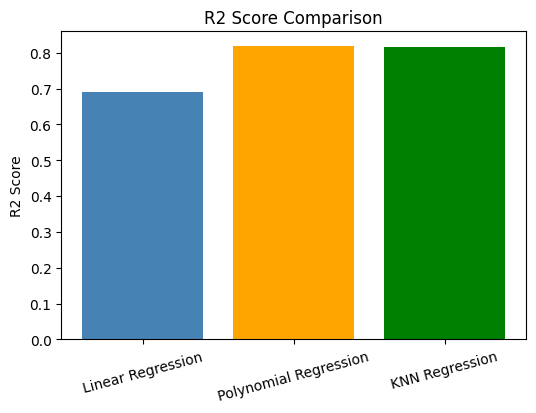

In [13]:
# Visual comparison of R2 Scores
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["R2 Score"], color=["steelblue", "orange", "green"])
plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.show()


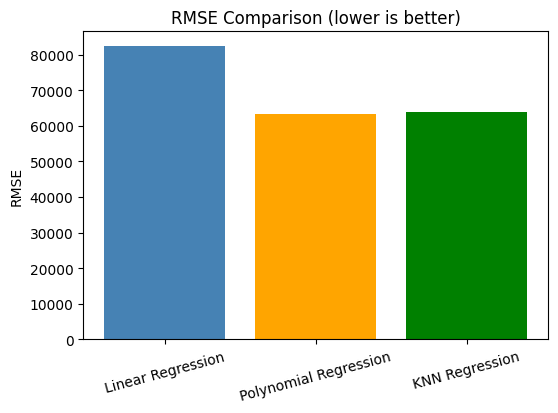

In [14]:
# Visual comparison of RMSE
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["RMSE"], color=["steelblue", "orange", "green"])
plt.title("RMSE Comparison (lower is better)")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()


## Step 10: Conclusion

Look at the table above:
- **Higher R2 Score** = better (closer to 1 means the model explains the data well)
- **Lower MSE and RMSE** = better (means smaller prediction errors)

Compare the three models and note which one performed best on this dataset, and think
about *why* that might be (for example: does the price vs. rooms relationship look
more like a straight line or a curve?).
